# Bilan global — 5 modèles × 2 datasets

Ce notebook agrège **tous les résultats produits par les notebooks 03 → 10** (3 baselines + 2 stratégies, sur Animals-10 et Imagewoof) et produit les visualisations comparatives utiles au rapport et à la soutenance.

## Source des données
Lecture **uniquement** des JSON locaux sur Drive :
- Animals-10 : `/content/drive/MyDrive/UTBM_PF22/results/results_*.json`
- Imagewoof : `/content/drive/MyDrive/UTBM_PF22/results/Imagewoof/results_*.json`

Aucune dépendance W&B requise.

## Sorties
- Tableau récap dans le notebook
- **8 figures PNG haute résolution** sauvegardées dans `results/comparison/` (prêtes pour `\includegraphics{...}`)

## 1) Setup : montage Drive, chemins, palette

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Montage Drive (silencieux si déjà monté ou en local)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    RESULTS_ROOT = '/content/drive/MyDrive/UTBM_PF22/results'
except Exception:
    # Fallback local : adapter si besoin
    RESULTS_ROOT = '../results'

RESULTS_ANIMALS = RESULTS_ROOT
RESULTS_IMAGEWOOF = os.path.join(RESULTS_ROOT, 'Imagewoof')
OUT_DIR = os.path.join(RESULTS_ROOT, 'comparison')
os.makedirs(OUT_DIR, exist_ok=True)

print('Animals-10 dir :', RESULTS_ANIMALS, '→ existe :', os.path.isdir(RESULTS_ANIMALS))
print('Imagewoof  dir :', RESULTS_IMAGEWOOF, '→ existe :', os.path.isdir(RESULTS_IMAGEWOOF))
print('Output dir     :', OUT_DIR)

# --- Couleurs cohérentes ---
# Couleur = modèle ; style/hachure = dataset.
MODEL_ORDER = [
    'BL 1(HF)',
    'BL 2(BF)',
    'BL 3(MIXTE)',
    'Strat 1(BF→HF)',
    'Strat 2(CoTrain)',
]
MODEL_COLORS = {
    'BL 1(HF)':         '#4C72B0',
    'BL 2(BF)':         '#55A868',
    'BL 3(MIXTE)':      '#C44E52',
    'Strat 1(BF→HF)':   '#8172B2',
    'Strat 2(CoTrain)': '#CCB974',
}
DATASETS = ['Animals-10', 'Imagewoof']
DATASET_HATCH = {'Animals-10': '', 'Imagewoof': '///'}

FILES = {
    'BL 1(HF)':         'results_baseline_HF.json',
    'BL 2(BF)':         'results_baseline_BF.json',
    'BL 3(MIXTE)':      'results_baseline_MIXTE.json',
    'Strat 1(BF→HF)':   'results_strategy1_transfer_learning.json',
    'Strat 2(CoTrain)': 'results_strategy2_cotraining_reweighting.json',
}

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 180, 'savefig.bbox': 'tight'})
print('\nSetup OK.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Animals-10 dir : /content/drive/MyDrive/UTBM_PF22/results → existe : True
Imagewoof  dir : /content/drive/MyDrive/UTBM_PF22/results/Imagewoof → existe : True
Output dir     : /content/drive/MyDrive/UTBM_PF22/results/comparison

Setup OK.


## 2) Chargement des 10 JSON dans un DataFrame unique

In [5]:
def _time_min(d):
    """Récupère le temps d'entraînement en minutes, quel que soit le format du JSON."""
    if 'training_time_min' in d:        # Strategy 2
        return float(d['training_time_min'])
    if 'total_time_min' in d:           # Strategy 1
        return float(d['total_time_min'])
    if 'training_time_sec' in d:        # Baselines
        return float(d['training_time_sec']) / 60.0
    return float('nan')

rows = []
missing = []
for dataset, base_dir in zip(DATASETS, [RESULTS_ANIMALS, RESULTS_IMAGEWOOF]):
    for model_name, fname in FILES.items():
        path = os.path.join(base_dir, fname)
        if not os.path.exists(path):
            missing.append((dataset, model_name, path))
            continue
        with open(path, 'r', encoding='utf-8') as f:
            d = json.load(f)
        rows.append({
            'dataset':       dataset,
            'model':         model_name,
            'accuracy_HF':   float(d.get('accuracy_HF',    np.nan)),
            'accuracy_BF':   float(d.get('accuracy_BF',    np.nan)),
            'accuracy_Mixte':float(d.get('accuracy_Mixte', np.nan)),
            'total_cost_CA': float(d.get('total_cost_CA',  np.nan)),
            'time_min':      _time_min(d),
        })

df = pd.DataFrame(rows)
df['robustness_gap'] = df['accuracy_HF'] - df['accuracy_BF']
# Efficacité = points de précision HF gagnés pour 1000 CA dépensés
df['accuracy_per_kCA'] = df['accuracy_HF'] / (df['total_cost_CA'] / 1000.0)

# Ordre stable
df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
df['dataset'] = pd.Categorical(df['dataset'], categories=DATASETS, ordered=True)
df = df.sort_values(['dataset', 'model']).reset_index(drop=True)

if missing:
    print('⚠️ JSON manquants :')
    for d, m, p in missing:
        print(f'   - {d:<11} | {m:<18} | {p}')
else:
    print(f'✅ Les {len(df)} JSON ont été chargés.')

display(df.round(2))

✅ Les 10 JSON ont été chargés.


,dataset,model,accuracy_HF,accuracy_BF,accuracy_Mixte,total_cost_CA,time_min,robustness_gap,accuracy_per_kCA
0,Animals-10,BL 1(HF),51.49,30.49,40.99,470400.0,1.39,21.00,0.11
1,Animals-10,BL 2(BF),59.68,63.70,61.69,424260.0,12.94,-4.02,0.14
2,Animals-10,BL 3(MIXTE),76.55,65.76,71.16,894660.0,14.15,10.79,0.09
3,Animals-10,Strat 1(BF→HF),78.16,58.07,68.11,400230.0,2.96,20.08,0.20
4,Animals-10,Strat 2(CoTrain),62.47,58.95,60.71,486720.0,1.95,3.52,0.13
5,Imagewoof,BL 1(HF),24.87,19.04,21.95,179800.0,0.39,5.83,0.14
6,Imagewoof,BL 2(BF),43.73,44.52,44.12,162520.0,1.00,-0.79,0.27
7,Imagewoof,BL 3(MIXTE),47.19,47.24,47.21,342320.0,1.36,-0.05,0.14
8,Imagewoof,Strat 1(BF→HF),53.68,44.82,49.25,153160.0,0.83,8.86,0.35
9,Imagewoof,Strat 2(CoTrain),39.20,39.81,39.50,183040.0,1.94,-0.61,0.21


## 3) Tableau récap + export CSV

In [6]:
# Pivot pour avoir un tableau lisible : lignes = modèles, colonnes = (dataset, métrique)
metrics = ['accuracy_HF', 'accuracy_BF', 'accuracy_Mixte', 'total_cost_CA', 'time_min']
wide = df.pivot(index='model', columns='dataset', values=metrics)
wide = wide.swaplevel(axis=1).sort_index(axis=1)

csv_path = os.path.join(OUT_DIR, 'comparison_summary.csv')
df.to_csv(csv_path, index=False)
print('CSV (long format) sauvé :', csv_path)

wide_path = os.path.join(OUT_DIR, 'comparison_summary_wide.csv')
wide.to_csv(wide_path)
print('CSV (wide format) sauvé :', wide_path)

print('\n=== TABLEAU RÉCAP (wide) ===')
display(wide.round(2))

# Top performer par dataset / métrique
print('\n=== MEILLEURS MODÈLES PAR DATASET ===')
for ds in DATASETS:
    sub = df[df['dataset'] == ds]
    print(f'\n--- {ds} ---')
    print(f"  Meilleur Test HF    : {sub.loc[sub['accuracy_HF'].idxmax(),    'model']} ({sub['accuracy_HF'].max():.2f}%)")
    print(f"  Meilleur Test BF    : {sub.loc[sub['accuracy_BF'].idxmax(),    'model']} ({sub['accuracy_BF'].max():.2f}%)")
    print(f"  Meilleur Test Mixte : {sub.loc[sub['accuracy_Mixte'].idxmax(), 'model']} ({sub['accuracy_Mixte'].max():.2f}%)")
    print(f"  Moins cher          : {sub.loc[sub['total_cost_CA'].idxmin(),  'model']} ({int(sub['total_cost_CA'].min())} CA)")
    print(f"  Plus efficace (HF/kCA): {sub.loc[sub['accuracy_per_kCA'].idxmax(), 'model']} ({sub['accuracy_per_kCA'].max():.4f})")

CSV (long format) sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/comparison_summary.csv
CSV (wide format) sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/comparison_summary_wide.csv

=== TABLEAU RÉCAP (wide) ===


dataset           Animals-10                                      \
                 accuracy_BF accuracy_HF accuracy_Mixte time_min   
model                                                              
BL 1(HF)               30.49       51.49          40.99     1.39   
BL 2(BF)               63.70       59.68          61.69    12.94   
BL 3(MIXTE)            65.76       76.55          71.16    14.15   
Strat 1(BF→HF)         58.07       78.16          68.11     2.96   
Strat 2(CoTrain)       58.95       62.47          60.71     1.95   

dataset                          Imagewoof                             \
                 total_cost_CA accuracy_BF accuracy_HF accuracy_Mixte   
model                                                                   
BL 1(HF)              470400.0       19.04       24.87          21.95   
BL 2(BF)              424260.0       44.52       43.73          44.12   
BL 3(MIXTE)           894660.0       47.24       47.19          47.21   
Strat 1(BF→HF)        400230.0       44.82       53.68          49.25   
Strat 2(CoTrain)      486720.0       39.81       39.20          39.50   

dataset                                  
                 time_min total_cost_CA  
model                                    
BL 1(HF)             0.39      179800.0  
BL 2(BF)             1.00      162520.0  
BL 3(MIXTE)          1.36      342320.0  
Strat 1(BF→HF)       0.83      153160.0  
Strat 2(CoTrain)     1.94      183040.0


=== MEILLEURS MODÈLES PAR DATASET ===

--- Animals-10 ---
  Meilleur Test HF    : Strat 1(BF→HF) (78.16%)
  Meilleur Test BF    : BL 3(MIXTE) (65.76%)
  Meilleur Test Mixte : BL 3(MIXTE) (71.16%)
  Moins cher          : Strat 1(BF→HF) (400230 CA)
  Plus efficace (HF/kCA): Strat 1(BF→HF) (0.1953)

--- Imagewoof ---
  Meilleur Test HF    : Strat 1(BF→HF) (53.68%)
  Meilleur Test BF    : BL 3(MIXTE) (47.24%)
  Meilleur Test Mixte : Strat 1(BF→HF) (49.25%)
  Moins cher          : Strat 1(BF→HF) (153160 CA)
  Plus efficace (HF/kCA): Strat 1(BF→HF) (0.3505)


## Figure 1 — Précisions HF / BF / Mixte (cross-dataset)
Barres groupées : couleur = modèle, hachure = dataset. On voit d'un coup d'œil quel modèle domine sur quel domaine et si la hiérarchie se conserve entre Animals-10 et Imagewoof.

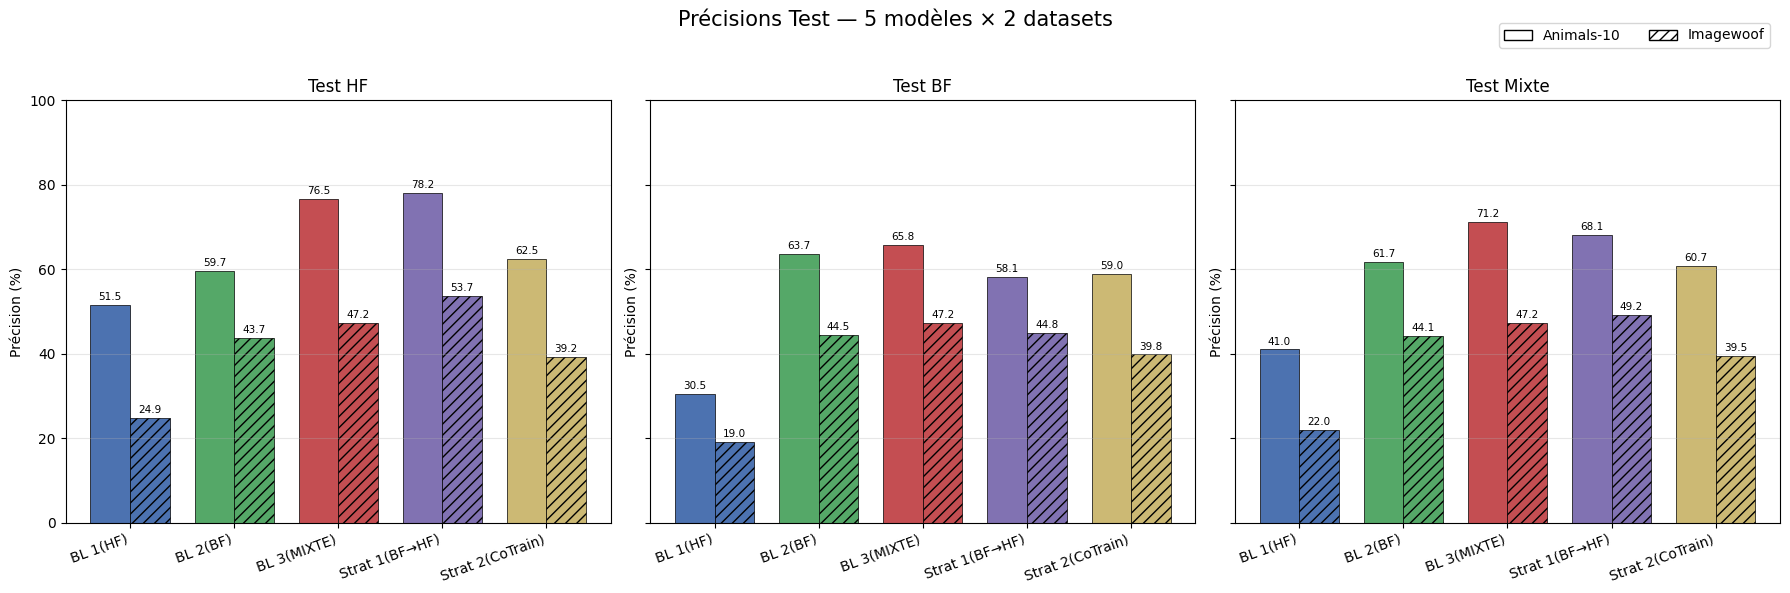

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig1_accuracy_grouped.png


In [7]:
metric_cols = ['accuracy_HF', 'accuracy_BF', 'accuracy_Mixte']
metric_labels = ['Test HF', 'Test BF', 'Test Mixte']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Précisions Test — 5 modèles × 2 datasets', fontsize=15)

x = np.arange(len(MODEL_ORDER))
width = 0.38
offsets = {'Animals-10': -width/2, 'Imagewoof': +width/2}

for ax, mcol, mlabel in zip(axes, metric_cols, metric_labels):
    for ds in DATASETS:
        sub = df[df['dataset'] == ds].set_index('model').reindex(MODEL_ORDER)
        vals = sub[mcol].values
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
        bars = ax.bar(x + offsets[ds], vals, width=width,
                      color=colors, edgecolor='black', linewidth=0.5,
                      hatch=DATASET_HATCH[ds], label=ds)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.7, f'{v:.1f}',
                        ha='center', va='bottom', fontsize=7.5)
    ax.set_title(mlabel)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
    ax.set_ylabel('Précision (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

# Légende globale pour les datasets (hachures)
ds_handles = [Patch(facecolor='white', edgecolor='black', hatch=DATASET_HATCH[d], label=d) for d in DATASETS]
fig.legend(handles=ds_handles, loc='upper right', bbox_to_anchor=(0.99, 0.97), ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig1_accuracy_grouped.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 2 — Pareto Coût vs Précision HF
Scatter « haut-gauche = mieux ». Permet d'identifier les modèles efficaces (haute précision pour peu de CA).

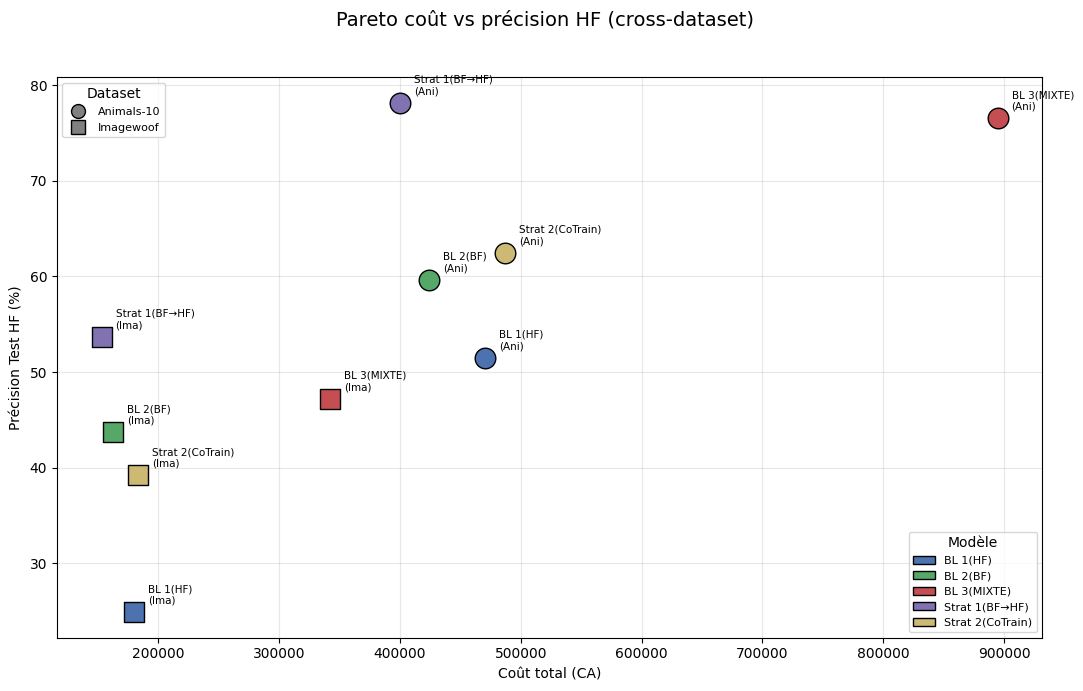

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig2_pareto_cost_vs_accuracy.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle('Pareto coût vs précision HF (cross-dataset)', fontsize=14)

DATASET_MARKER = {'Animals-10': 'o', 'Imagewoof': 's'}

for _, row in df.iterrows():
    ax.scatter(
        row['total_cost_CA'], row['accuracy_HF'],
        s=220, color=MODEL_COLORS[row['model']],
        marker=DATASET_MARKER[row['dataset']],
        edgecolor='black', linewidth=1.0, zorder=3,
    )
    ax.annotate(f"{row['model']}\n({row['dataset'][:3]})",
                (row['total_cost_CA'], row['accuracy_HF']),
                xytext=(10, 6), textcoords='offset points', fontsize=7.5)

ax.set_xlabel('Coût total (CA)')
ax.set_ylabel('Précision Test HF (%)')
ax.grid(alpha=0.3)

model_handles = [Patch(facecolor=MODEL_COLORS[m], edgecolor='black', label=m) for m in MODEL_ORDER]
ds_handles = [plt.Line2D([0],[0], marker=DATASET_MARKER[d], color='w', markerfacecolor='gray',
                          markeredgecolor='black', markersize=10, label=d) for d in DATASETS]
leg1 = ax.legend(handles=model_handles, title='Modèle', loc='lower right', fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=ds_handles, title='Dataset', loc='upper left', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
out = os.path.join(OUT_DIR, 'fig2_pareto_cost_vs_accuracy.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 3 — Gap de robustesse (Test HF − Test BF)
Un gap proche de **0** = modèle robuste (généralise au domaine BF). Un gap **positif élevé** = surapprentissage du domaine propre.

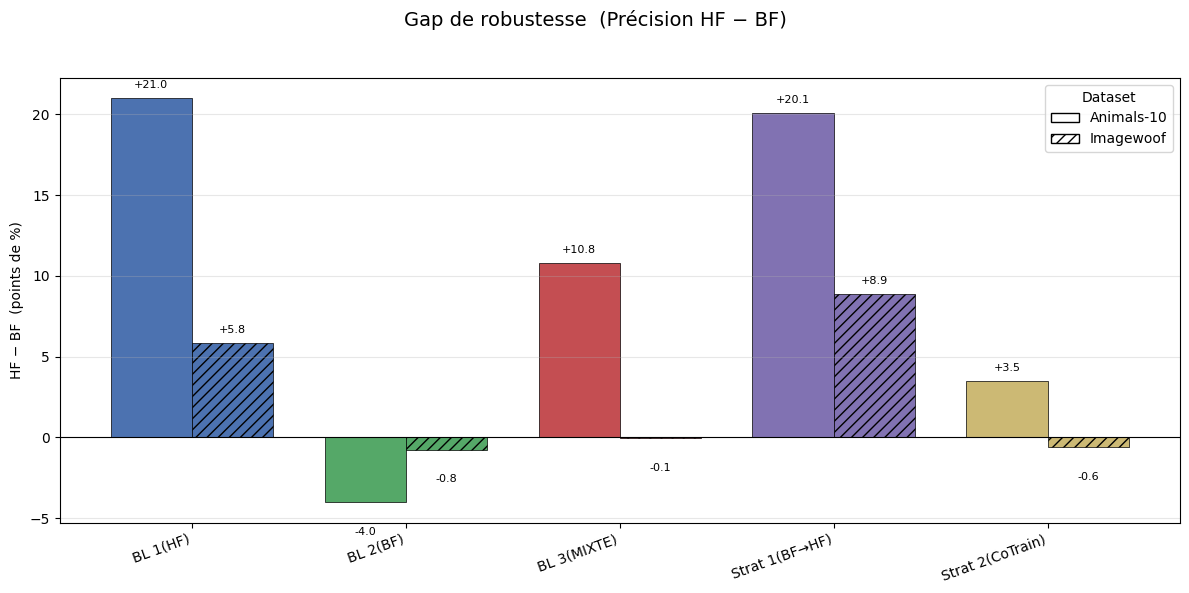

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig3_robustness_gap.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Gap de robustesse  (Précision HF − BF)', fontsize=14)

x = np.arange(len(MODEL_ORDER))
width = 0.38
offsets = {'Animals-10': -width/2, 'Imagewoof': +width/2}

for ds in DATASETS:
    sub = df[df['dataset'] == ds].set_index('model').reindex(MODEL_ORDER)
    vals = sub['robustness_gap'].values
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(x + offsets[ds], vals, width=width,
                  color=colors, edgecolor='black', linewidth=0.5,
                  hatch=DATASET_HATCH[ds], label=ds)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (0.5 if v >= 0 else -1.5),
                    f'{v:+.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
ax.set_ylabel('HF − BF  (points de %)')
ax.grid(axis='y', alpha=0.3)

ds_handles = [Patch(facecolor='white', edgecolor='black', hatch=DATASET_HATCH[d], label=d) for d in DATASETS]
ax.legend(handles=ds_handles, title='Dataset', loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig3_robustness_gap.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 4 — Efficacité (Précision HF par 1000 CA)
Un modèle très précis mais hors de prix n'est pas forcément souhaitable. Cette métrique répond à : « combien je gagne de points de précision HF pour 1000 crédits dépensés ? ».

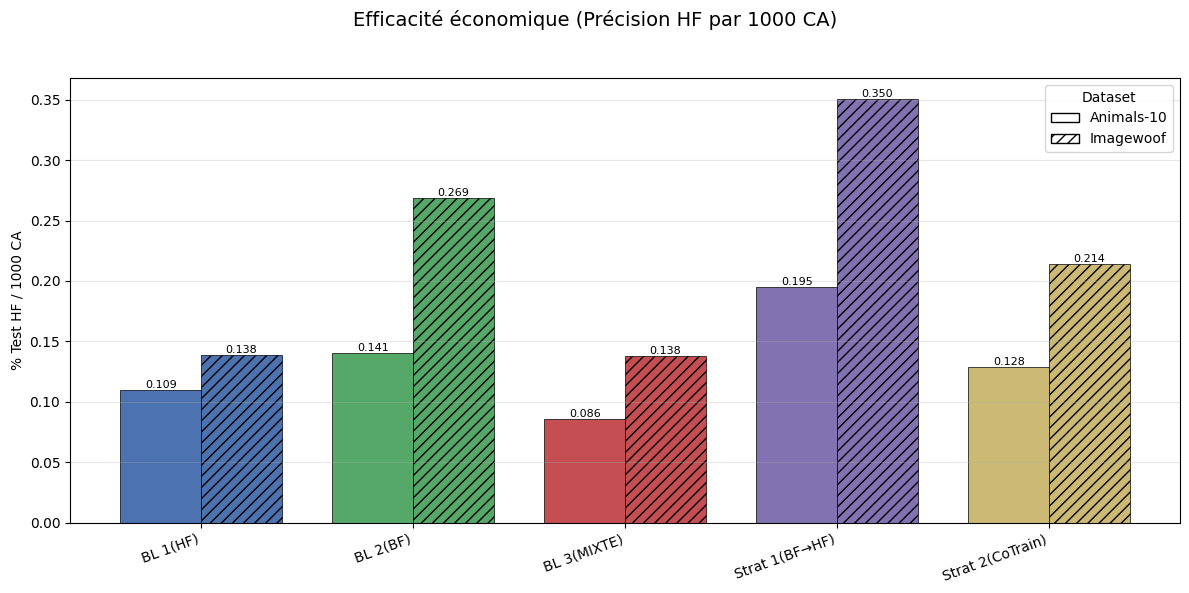

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig4_efficiency.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Efficacité économique (Précision HF par 1000 CA)', fontsize=14)

x = np.arange(len(MODEL_ORDER))
width = 0.38
offsets = {'Animals-10': -width/2, 'Imagewoof': +width/2}

for ds in DATASETS:
    sub = df[df['dataset'] == ds].set_index('model').reindex(MODEL_ORDER)
    vals = sub['accuracy_per_kCA'].values
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(x + offsets[ds], vals, width=width,
                  color=colors, edgecolor='black', linewidth=0.5,
                  hatch=DATASET_HATCH[ds], label=ds)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
ax.set_ylabel('% Test HF / 1000 CA')
ax.grid(axis='y', alpha=0.3)

ds_handles = [Patch(facecolor='white', edgecolor='black', hatch=DATASET_HATCH[d], label=d) for d in DATASETS]
ax.legend(handles=ds_handles, title='Dataset', loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig4_efficiency.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 5 — Heatmap récapitulative
Vue dense : tous les chiffres importants dans une seule image, gradient de couleur pour repérer les extrêmes.

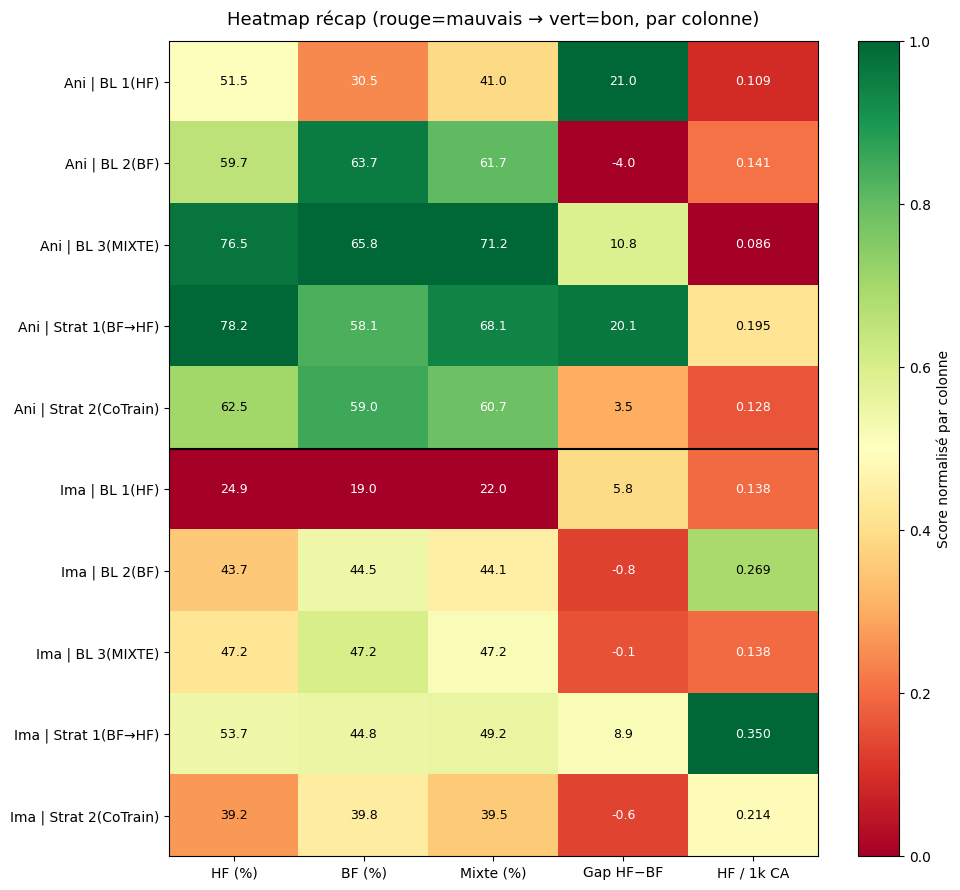

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig5_heatmap_summary.png


In [11]:
# Matrice : lignes = (dataset, modèle), colonnes = métriques
heat_cols = ['accuracy_HF', 'accuracy_BF', 'accuracy_Mixte', 'robustness_gap', 'accuracy_per_kCA']
heat_col_labels = ['HF (%)', 'BF (%)', 'Mixte (%)', 'Gap HF−BF', 'HF / 1k CA']

rows_lbl = []
heat = []
for ds in DATASETS:
    for m in MODEL_ORDER:
        sub = df[(df['dataset'] == ds) & (df['model'] == m)]
        if not sub.empty:
            heat.append([sub.iloc[0][c] for c in heat_cols])
            rows_lbl.append(f'{ds[:3]} | {m}')
heat = np.array(heat)

# Normalisation par colonne (chaque métrique a ses propres extrêmes)
heat_norm = np.zeros_like(heat, dtype=float)
for j in range(heat.shape[1]):
    col = heat[:, j]
    if np.nanmax(col) > np.nanmin(col):
        heat_norm[:, j] = (col - np.nanmin(col)) / (np.nanmax(col) - np.nanmin(col))

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(heat_norm, aspect='auto', cmap='RdYlGn')

ax.set_xticks(np.arange(len(heat_col_labels)))
ax.set_xticklabels(heat_col_labels)
ax.set_yticks(np.arange(len(rows_lbl)))
ax.set_yticklabels(rows_lbl)

# Annotations avec les vraies valeurs (pas les normalisées)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat[i, j]
        if not np.isnan(v):
            txt_color = 'black' if 0.25 < heat_norm[i, j] < 0.75 else 'white'
            if heat_cols[j] == 'accuracy_per_kCA':
                s = f'{v:.3f}'
            else:
                s = f'{v:.1f}'
            ax.text(j, i, s, ha='center', va='center', color=txt_color, fontsize=9)

# Séparateur visuel entre les 2 datasets
ax.axhline(len(MODEL_ORDER) - 0.5, color='black', linewidth=1.5)

ax.set_title('Heatmap récap (rouge=mauvais → vert=bon, par colonne)', fontsize=13, pad=12)
fig.colorbar(im, ax=ax, label='Score normalisé par colonne')

plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig5_heatmap_summary.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 6 — Temps d'entraînement

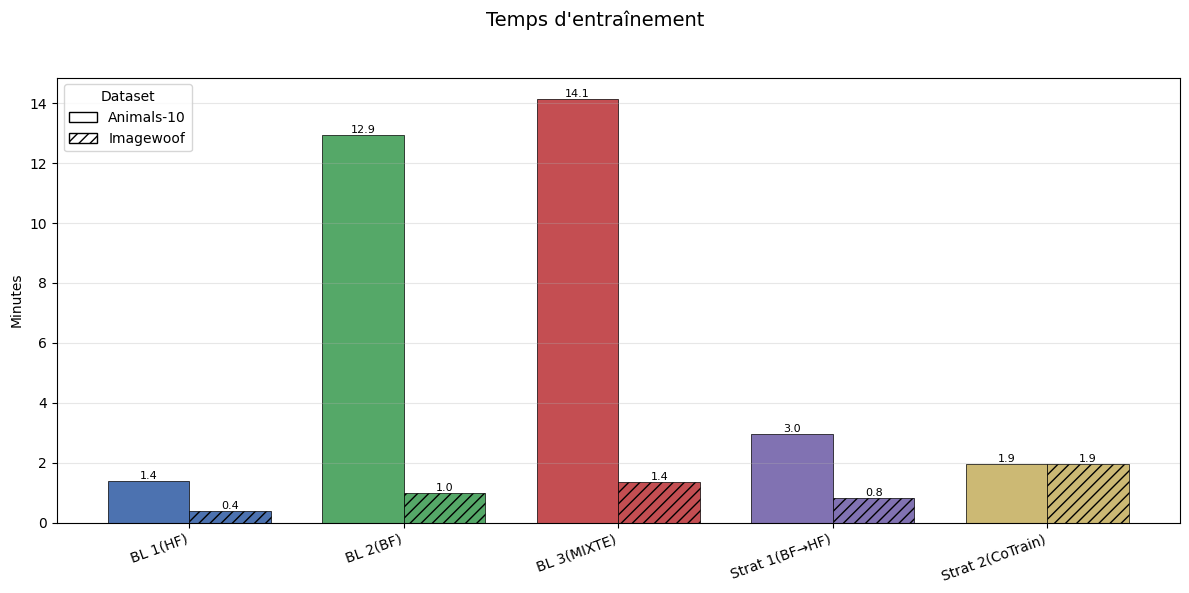

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig6_training_time.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Temps d'entraînement", fontsize=14)

x = np.arange(len(MODEL_ORDER))
width = 0.38
offsets = {'Animals-10': -width/2, 'Imagewoof': +width/2}

for ds in DATASETS:
    sub = df[df['dataset'] == ds].set_index('model').reindex(MODEL_ORDER)
    vals = sub['time_min'].values
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(x + offsets[ds], vals, width=width,
                  color=colors, edgecolor='black', linewidth=0.5,
                  hatch=DATASET_HATCH[ds], label=ds)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
ax.set_ylabel('Minutes')
ax.grid(axis='y', alpha=0.3)

ds_handles = [Patch(facecolor='white', edgecolor='black', hatch=DATASET_HATCH[d], label=d) for d in DATASETS]
ax.legend(handles=ds_handles, title='Dataset', loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig6_training_time.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 7 — Généralisation cross-dataset (scatter pairé)
Chaque modèle a deux points (un par dataset) reliés par une ligne. **Une ligne plate** = le modèle donne le même ordre de performance sur les 2 datasets (conclusion robuste). **Une ligne pentue** = les conclusions ne se généralisent pas.

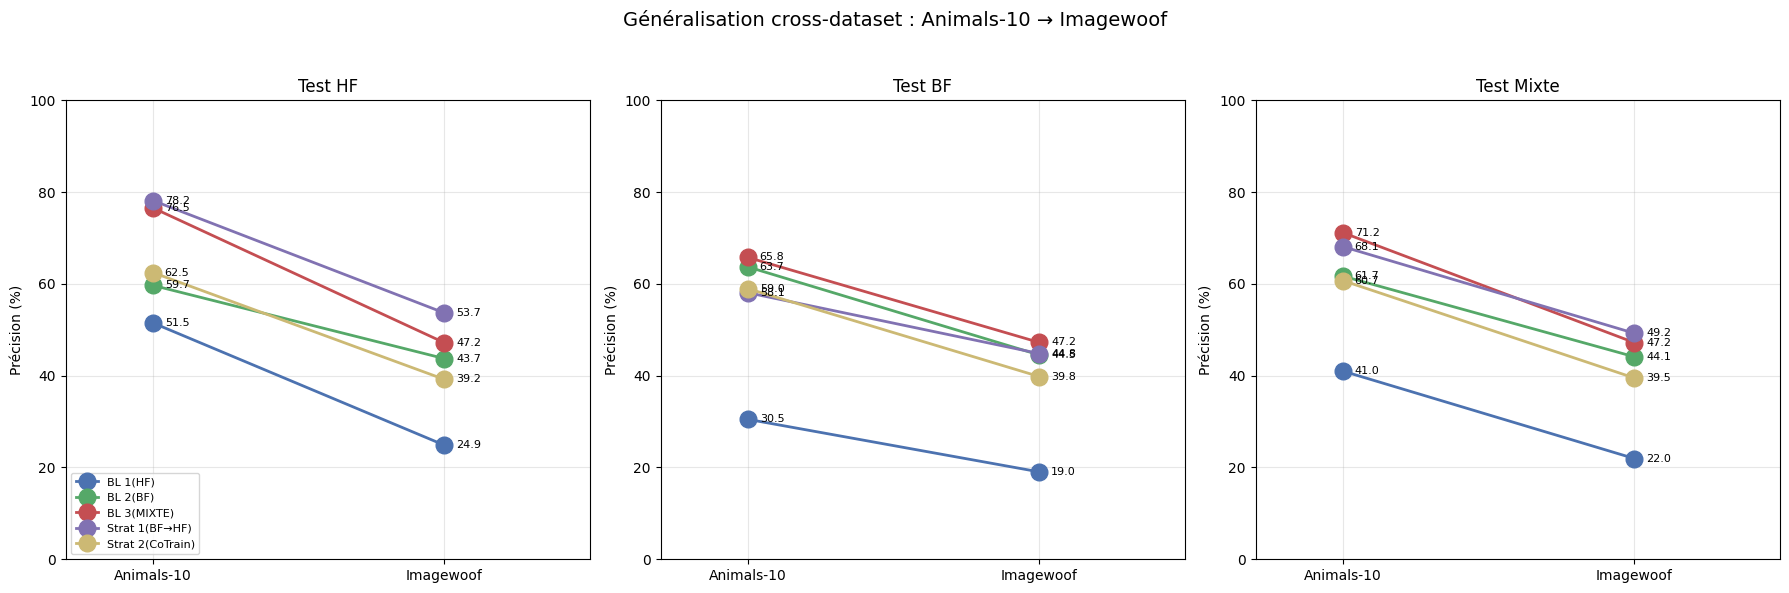

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig7_cross_dataset_paired.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('Généralisation cross-dataset : Animals-10 → Imagewoof', fontsize=14)

metric_cols = ['accuracy_HF', 'accuracy_BF', 'accuracy_Mixte']
metric_labels = ['Test HF', 'Test BF', 'Test Mixte']

for ax, mcol, mlabel in zip(axes, metric_cols, metric_labels):
    for m in MODEL_ORDER:
        sub = df[df['model'] == m].set_index('dataset').reindex(DATASETS)
        ys = sub[mcol].values
        if np.isnan(ys).any():
            continue
        ax.plot([0, 1], ys, marker='o', markersize=12, linewidth=2,
                color=MODEL_COLORS[m], label=m)
        for x_i, y_i in zip([0, 1], ys):
            ax.text(x_i + 0.04, y_i, f'{y_i:.1f}', va='center', fontsize=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(DATASETS)
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(0, 100)
    ax.set_title(mlabel)
    ax.set_ylabel('Précision (%)')
    ax.grid(alpha=0.3)
    if mcol == 'accuracy_HF':
        ax.legend(fontsize=8, loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig7_cross_dataset_paired.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

## Figure 8 — Classement global
Rank moyen de chaque modèle sur les 3 métriques (HF, BF, Mixte), agrégé sur les 2 datasets. Le modèle avec le plus petit rank moyen est le plus systématiquement performant.

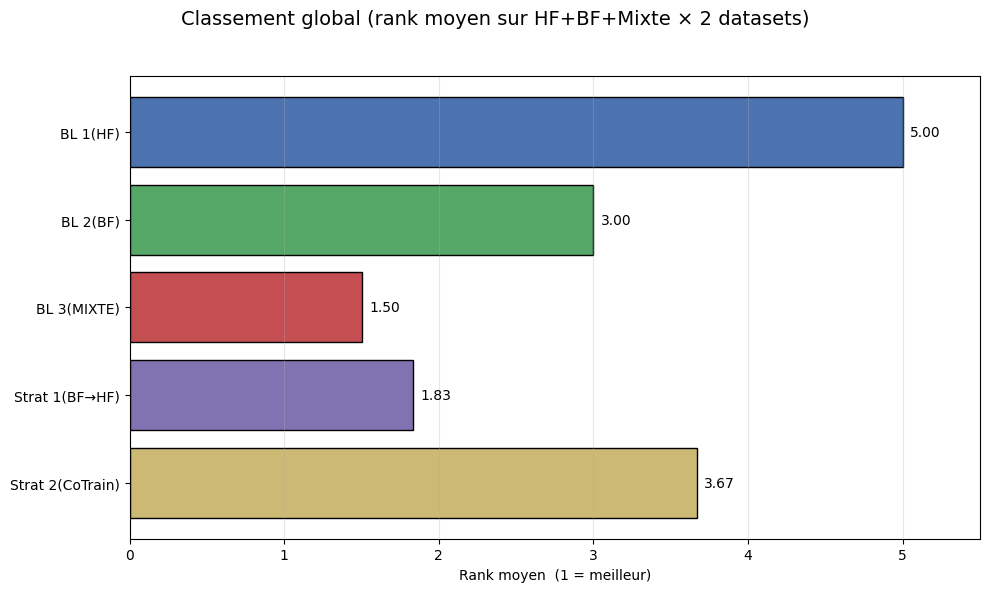

Sauvé : /content/drive/MyDrive/UTBM_PF22/results/comparison/fig8_global_ranking.png

=== CLASSEMENT GLOBAL ===
  1. BL 3(MIXTE)          (rank moyen = 1.50)
  2. Strat 1(BF→HF)       (rank moyen = 1.83)
  3. BL 2(BF)             (rank moyen = 3.00)
  4. Strat 2(CoTrain)     (rank moyen = 3.67)
  5. BL 1(HF)             (rank moyen = 5.00)


In [14]:
# Rank par dataset, par métrique (1 = meilleur)
ranks = []
for ds in DATASETS:
    sub = df[df['dataset'] == ds].copy()
    for col in ['accuracy_HF', 'accuracy_BF', 'accuracy_Mixte']:
        sub[f'rank_{col}'] = sub[col].rank(ascending=False, method='min')
    ranks.append(sub)
ranks_df = pd.concat(ranks, ignore_index=True)

avg_rank = ranks_df.groupby('model', observed=True)[
    ['rank_accuracy_HF', 'rank_accuracy_BF', 'rank_accuracy_Mixte']
].mean().mean(axis=1).reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Classement global (rank moyen sur HF+BF+Mixte × 2 datasets)', fontsize=14)

colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
bars = ax.barh(MODEL_ORDER, avg_rank.values, color=colors, edgecolor='black')
for bar, v in zip(bars, avg_rank.values):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.2f}',
            va='center', fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Rank moyen  (1 = meilleur)')
ax.set_xlim(0, 5.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
out = os.path.join(OUT_DIR, 'fig8_global_ranking.png')
plt.savefig(out)
plt.show()
print('Sauvé :', out)

print('\n=== CLASSEMENT GLOBAL ===')
for i, (m, r) in enumerate(avg_rank.sort_values().items(), start=1):
    print(f'  {i}. {m:<20} (rank moyen = {r:.2f})')

## Conclusion / récap auto
Synthèse textuelle s'appuyant sur les chiffres réels lus dans les JSON.

In [15]:
print('='*72)
print('BILAN GLOBAL — 5 MODÈLES × 2 DATASETS')
print('='*72)

# Meilleurs absolus
print('\n— Meilleurs absolus —')
for ds in DATASETS:
    sub = df[df['dataset'] == ds]
    best_hf = sub.loc[sub['accuracy_HF'].idxmax()]
    best_mix = sub.loc[sub['accuracy_Mixte'].idxmax()]
    cheapest = sub.loc[sub['total_cost_CA'].idxmin()]
    print(f'  {ds}:')
    print(f'    Top HF        : {best_hf["model"]:<18} → {best_hf["accuracy_HF"]:.2f}%')
    print(f'    Top Mixte     : {best_mix["model"]:<18} → {best_mix["accuracy_Mixte"]:.2f}%')
    print(f'    Moins cher    : {cheapest["model"]:<18} → {int(cheapest["total_cost_CA"])} CA')

# Généralisation cross-dataset : delta absolu HF entre datasets
print('\n— Généralisation cross-dataset (Δ = Animals-10 − Imagewoof, sur HF) —')
wide_hf = df.pivot(index='model', columns='dataset', values='accuracy_HF')
wide_hf['Δ'] = wide_hf['Animals-10'] - wide_hf['Imagewoof']
for m in MODEL_ORDER:
    if m in wide_hf.index:
        a, i, d = wide_hf.loc[m, 'Animals-10'], wide_hf.loc[m, 'Imagewoof'], wide_hf.loc[m, 'Δ']
        print(f'  {m:<20} : Animals-10={a:5.2f}%  |  Imagewoof={i:5.2f}%  |  Δ={d:+5.2f}')

mean_delta = wide_hf['Δ'].mean()
print(f'\n  Δ moyen sur les 5 modèles : {mean_delta:+.2f} points')
if mean_delta > 5:
    print('  → Imagewoof est nettement plus difficile (chiens fins de mêmes classes).')
elif mean_delta < -5:
    print('  → Imagewoof est nettement plus facile (peu probable, à vérifier).')
else:
    print('  → Difficulté comparable entre les 2 datasets.')

# Classement final
print('\n— Classement global (rank moyen sur HF+BF+Mixte × 2 datasets) —')
for i, (m, r) in enumerate(avg_rank.sort_values().items(), start=1):
    print(f'  {i}. {m:<20} (rank moyen = {r:.2f})')

print('\n' + '='*72)
print(f'✅ 8 figures + 2 CSV sauvegardés dans :\n   {OUT_DIR}')
print('='*72)

BILAN GLOBAL — 5 MODÈLES × 2 DATASETS

— Meilleurs absolus —
  Animals-10:
    Top HF        : Strat 1(BF→HF)     → 78.16%
    Top Mixte     : BL 3(MIXTE)        → 71.16%
    Moins cher    : Strat 1(BF→HF)     → 400230 CA
  Imagewoof:
    Top HF        : Strat 1(BF→HF)     → 53.68%
    Top Mixte     : Strat 1(BF→HF)     → 49.25%
    Moins cher    : Strat 1(BF→HF)     → 153160 CA

— Généralisation cross-dataset (Δ = Animals-10 − Imagewoof, sur HF) —
  BL 1(HF)             : Animals-10=51.49%  |  Imagewoof=24.87%  |  Δ=+26.63
  BL 2(BF)             : Animals-10=59.68%  |  Imagewoof=43.73%  |  Δ=+15.95
  BL 3(MIXTE)          : Animals-10=76.55%  |  Imagewoof=47.19%  |  Δ=+29.36
  Strat 1(BF→HF)       : Animals-10=78.16%  |  Imagewoof=53.68%  |  Δ=+24.48
  Strat 2(CoTrain)     : Animals-10=62.47%  |  Imagewoof=39.20%  |  Δ=+23.28

  Δ moyen sur les 5 modèles : +23.94 points
  → Imagewoof est nettement plus difficile (chiens fins de mêmes classes).

— Classement global (rank moyen sur HF+BF